Below is the 5th self-designed architecture: GNN + Differentiable Rule-Gated Neuro-Symbolic Classifier.

This one is different from the earlier tree/prototype/autoencoder/SVM hybrids because the verifier is trained inside the neural network. It learns fuzzy, differentiable rules over interpretable relational features such as SCOAP, distance-to-PO, fanout, and k-hop neighborhood features. This connects naturally to your paper, where relational features are shown to be critical for separability and are also used for prototype-style interpretability.

/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_scatter/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: /home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_cluster/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
/home/rrk307/anaconda3/envs/gnn_circuits/lib/python3.10/site-packages/torch_geometric/typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-

Device: cpu
Classes: ['bridging', 'clean', 'glitch', 'stuck_at']
Number of classes: 4
Clean class index: 1
Fault class indices: [0, 2, 3]
Gate vocabulary: ['and', 'nand', 'nor', 'not', 'or', 'other', 'xor']
Gate one-hot dimension: 7

Total netlists: 30
Train netlists: 24
Test netlists:  6
Validation netlists: 0  (paper-style protocol uses no validation split)

Train netlists (24):
-------------------
01. Priority.v
02. adder.v
03. arbiter.v
04. bar.v
05. c1355.v
06. c17.v
07. c1908.v
08. c2670.v
09. c499.v
10. c5315.v
11. c6288.v
12. c7552.v
13. c880.v
14. ctrl.v
15. div.v
16. i2c.v
17. int2float.v
18. log2.v
19. max.v
20. multiplier.v
21. router.v
22. sin.v
23. square.v
24. voter.v

Test netlists (6):
------------------
01. c3540.v
02. c432.v
03. cavlc.v
04. dec.v
05. memctrl.v
06. sqrt.v

Split sanity check:
-------------------
Train and Test overlap: []

No overlap found between train/test netlists.

Built graphs: train=24, test=6
Initial input dimension: 18

Test graph netlists and

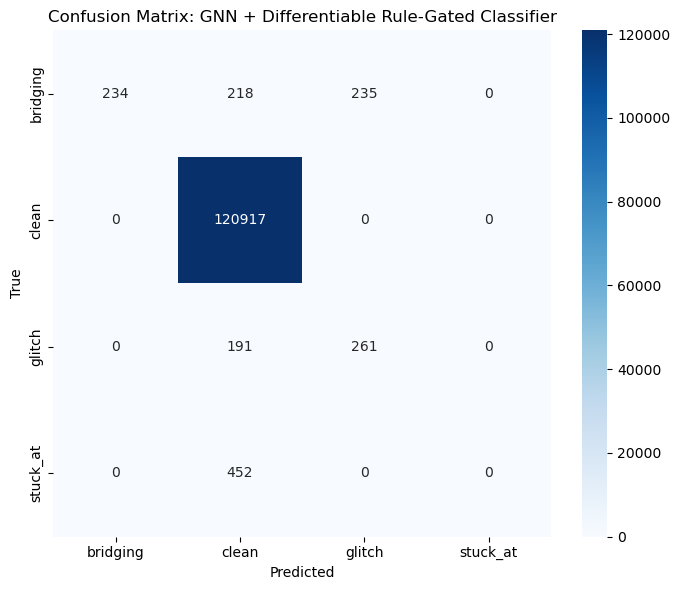


Test rule-gate diagnostics:
  Clean-strength mean: 4.3210
  Clean-strength 95pct:6.1460

bridging:
  threshold:                  0.8850
  true bridging score mean:     0.8246
  true bridging score 5pct:     0.5737
  true bridging gate mean:      0.8574
  clean score mean:            0.0196
  clean score 95pct:           0.1047
  clean score 99pct:           0.1047
  clean gate 99pct:            0.2616

glitch:
  threshold:                  0.4850
  true glitch score mean:     0.9210
  true glitch score 5pct:     0.3850
  true glitch gate mean:      0.9187
  clean score mean:            0.0164
  clean score 95pct:           0.0887
  clean score 99pct:           0.0887
  clean gate 99pct:            0.2217

stuck_at:
  threshold:                  0.9950
  true stuck_at score mean:     0.9833
  true stuck_at score 5pct:     0.9761
  true stuck_at gate mean:      0.9640
  clean score mean:            0.0140
  clean score 95pct:           0.0763
  clean score 99pct:           0.0763
  clea

In [1]:
# ============================================================
# Paper-Protocol Self-Designed Architecture 5:
# GNN + Differentiable Rule-Gated Neuro-Symbolic Classifier
# for Circuit Fault Detection from Enhanced CSVs
#
# Goal:
#   Improve precision for hard fault classes, especially bridging and stuck_at,
#   using differentiable rule gates over interpretable relational features.
#
# Stage 1:
#   Long-Short-GNN encoder
#       - short-view edge-aware GAT
#       - long-view multi-scale APPNP
#
# Stage 2:
#   Differentiable fuzzy rule bank
#       - learns class-specific soft rules over relational/testability features
#       - each rule is a soft prototype/conjunction in feature space
#       - clean-rule evidence suppresses clean -> fault false positives
#       - fault-rule evidence gates GNN fault logits
#
# Final classifier:
#   final_fault_logit = GNN_fault_logit + rule_gate_logit
#   final_clean_logit = GNN_clean_logit + clean_rule_evidence
#
# Paper-protocol refinement:
#   - 80/20 train/test split by netlist_file
#   - no validation netlists
#   - held-out test netlists printed explicitly
#   - fixed 100 epochs
#   - paper-close GNN settings: hidden_dim=64, dropout=0.4, lr=7e-4
#   - train-only node/edge normalization
#   - rule-bank initialization from train graphs only
#   - thresholds calibrated from train graphs only
#   - final metrics reported on held-out test netlists
#
# Inputs:
#   nodes_enhanced.csv
#   edges_enhanced.csv
#
# This cell defines:
#   nodes_df, edges_df, train_nets, test_nets
# and creates empty val_nets / val_graphs placeholders for compatibility.
# ============================================================


# ============================================================
# 1. Imports and configuration
# ============================================================

import os
import re
import math
import random
import warnings
from pathlib import Path
from typing import List, Dict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

try:
    from torch_geometric.data import Data
    from torch_geometric.loader import DataLoader
    from torch_geometric.nn import (
        GATConv,
        APPNP,
        global_mean_pool,
        global_max_pool,
    )
except Exception as e:
    raise RuntimeError(
        "PyTorch Geometric is required. Install a PyG version compatible "
        "with your PyTorch/CUDA setup before running this notebook."
    ) from e


# -------------------------
# Reproducibility
# -------------------------
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)


# -------------------------
# Files
# -------------------------
NODES_FILE = "nodes_enhanced.csv"
EDGES_FILE = "edges_enhanced.csv"


# -------------------------
# Paper-style split settings
# -------------------------
TEST_RATIO = 0.20

# The paper-style notebooks generally use clean topology when available.
# Use "union" only when you intentionally want clean + faulted topology.
EDGE_MODE = "clean"       # choices: "clean", "union"


# -------------------------
# GNN backbone settings
# -------------------------
EPOCHS = 100

LR = 7e-4
WEIGHT_DECAY = 5e-4

HID = 64
DROPOUT = 0.4

SHORT_GAT_LAYERS = 2
SHORT_GAT_HEADS = 4

LONG_PROP_STEPS_LIST = [3, 10]
LONG_ALPHA = 0.10

BATCH_SIZE = 1

MAX_FAULT_NODES_PER_CLASS_PER_GRAPH = 512
CLEAN_TO_FAULT_RATIO = 1.0
HARD_CLEAN_FRACTION = 0.50

# Model selection:
# "test_loss" mimics paper-style notebooks where the held-out split is monitored.
# "train_loss" avoids selecting checkpoints on the held-out test split.
MODEL_SELECTION_CRITERION = "test_loss"     # choices: "test_loss", "train_loss"


# -------------------------
# Differentiable rule-bank settings
# -------------------------
FAULT_RULES_PER_CLASS = 8
CLEAN_RULES = 10

RULE_FEATURE_NOISE = 0.08
MIN_RULE_SCALE = 0.15

FINAL_RULE_SCALE = 1.25
FINAL_CLEAN_BOOST = 0.80

# Loss terms.
MAIN_CE_LOSS_WEIGHT = 1.0
AUX_GNN_CE_LOSS_WEIGHT = 0.35
RULE_BCE_LOSS_WEIGHT = 0.80

CLEAN_RULE_MARGIN_LOSS_WEIGHT = 0.40
FAULT_RULE_MARGIN_LOSS_WEIGHT = 0.15

CLEAN_RULE_MARGIN = 1.0
FAULT_RULE_MARGIN = 0.50

# Mild entropy/sparsity-like regularization on feature-selection weights.
RULE_FEATURE_ENTROPY_WEIGHT = 0.005


# -------------------------
# Train-only threshold calibration
# -------------------------
THRESHOLD_GRID = np.linspace(0.05, 0.995, 190)

RECALL_FLOOR_BY_CLASS_NAME = {
    "bridging": 0.82,
    "glitch": 0.88,
    "stuck_at": 0.94,
}

BETA_BY_CLASS_NAME = {
    "bridging": 0.35,
    "glitch": 0.75,
    "stuck_at": 0.50,
}

POST_THRESHOLD_OFFSET_BY_CLASS_NAME = {
    "bridging": 0.04,
    "glitch": 0.00,
    "stuck_at": 0.02,
}


# -------------------------
# Optional prior-aware cap
# -------------------------
USE_PRIOR_AWARE_CAP = True

PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME = {
    "bridging": 1.5,
    "glitch": 2.5,
    "stuck_at": 2.5,
}

MIN_CAP_PER_GRAPH_BY_CLASS_NAME = {
    "bridging": 10,
    "glitch": 10,
    "stuck_at": 10,
}


PRINT_EVERY = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)


# ============================================================
# 2. Load enhanced CSV files
# ============================================================

nodes_df = pd.read_csv(NODES_FILE)
edges_df = pd.read_csv(EDGES_FILE)

required_node_cols = [
    "netlist_file", "fault_type", "node_id", "gate_type", "label",
    "in_degree", "out_degree", "total_degree", "path_depth",
    "CC0_exact", "CC1_exact", "CO_exact", "dist_to_PO",
    "fanout", "fanout_norm", "gate_delay",
]

required_edge_cols = [
    "netlist_file", "fault_type", "src_node", "dst_node",
]

for c in required_node_cols:
    if c not in nodes_df.columns:
        raise ValueError(f"Missing required node column: {c}")

for c in required_edge_cols:
    if c not in edges_df.columns:
        raise ValueError(f"Missing required edge column: {c}")

if "fan_out" not in edges_df.columns:
    if "fanout" in edges_df.columns:
        edges_df = edges_df.rename(columns={"fanout": "fan_out"})
    else:
        warnings.warn("edges_enhanced.csv has no fan_out column. Using fan_out=1.0.")
        edges_df["fan_out"] = 1.0


for c in ["netlist_file", "fault_type", "node_id", "gate_type"]:
    nodes_df[c] = nodes_df[c].astype(str)

for c in ["netlist_file", "fault_type", "src_node", "dst_node"]:
    edges_df[c] = edges_df[c].astype(str)


base_num_cols = [
    "in_degree",
    "out_degree",
    "total_degree",
    "path_depth",
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout",
    "fanout_norm",
    "gate_delay",
]

for c in base_num_cols:
    nodes_df[c] = (
        pd.to_numeric(nodes_df[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .astype(np.float32)
    )

nodes_df["label"] = (
    pd.to_numeric(nodes_df["label"], errors="coerce")
    .fillna(0)
    .astype(int)
)

edges_df["fan_out"] = (
    pd.to_numeric(edges_df["fan_out"], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(1.0)
    .astype(np.float32)
)


# ============================================================
# 3. Encode labels and gate types
# ============================================================

le = LabelEncoder()
nodes_df["fault_cls"] = le.fit_transform(nodes_df["fault_type"])

class_names = list(le.classes_)
class_to_idx = {c: i for i, c in enumerate(class_names)}
num_classes = len(class_names)

if "clean" not in class_to_idx:
    raise ValueError("Expected a 'clean' class in fault_type.")

clean_idx = class_to_idx["clean"]

fault_class_indices = [i for i in range(num_classes) if i != clean_idx]
fault_idx_to_local = {cls_idx: j for j, cls_idx in enumerate(fault_class_indices)}
local_to_fault_idx = {j: cls_idx for cls_idx, j in fault_idx_to_local.items()}

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Clean class index:", clean_idx)
print("Fault class indices:", fault_class_indices)


def canonical_gate_type(gate_type: str) -> str:
    s = str(gate_type).strip().lower()
    s = re.sub(r"[^a-z0-9_]+", "_", s)

    if s in {"sa0", "sa1", "bridge", "glitch"}:
        return "other"
    if s.startswith("sa0") or s.startswith("sa1"):
        return "other"
    if s.startswith("br_") or s.startswith("bridge"):
        return "other"
    if s.startswith("gl_") or s.startswith("glitch"):
        return "other"

    if s.startswith("nand"):
        return "nand"
    if s.startswith("and"):
        return "and"
    if s.startswith("nor"):
        return "nor"
    if s.startswith("or"):
        return "or"
    if s.startswith("xnor"):
        return "xnor"
    if s.startswith("xor"):
        return "xor"
    if s.startswith("inv") or s.startswith("not"):
        return "not"
    if s.startswith("buf") or s.startswith("buff"):
        return "buf"
    if s.startswith("mux"):
        return "mux"
    if s.startswith("dff") or s.startswith("sdff") or s.startswith("ff"):
        return "dff"
    if s.startswith("lat"):
        return "latch"
    if s in {"pi", "po"}:
        return s

    return "other"


nodes_df["gate_canon"] = nodes_df["gate_type"].map(canonical_gate_type)

gate_vocab = sorted(nodes_df["gate_canon"].unique().tolist())
if "other" not in gate_vocab:
    gate_vocab.append("other")
gate_vocab = sorted(gate_vocab)

g2i = {g: i for i, g in enumerate(gate_vocab)}
GATE_DIM = len(gate_vocab)

print("Gate vocabulary:", gate_vocab)
print("Gate one-hot dimension:", GATE_DIM)


# ============================================================
# 4. Paper-style 80/20 train/test split by netlist
# ============================================================

# Use drop_duplicates order, matching the paper-code scripts.
netlists = nodes_df["netlist_file"].drop_duplicates().values

if len(netlists) < 4:
    raise ValueError(
        f"Only {len(netlists)} netlists found. Need at least 4 for train/test."
    )

train_nets, test_nets = train_test_split(
    netlists,
    test_size=TEST_RATIO,
    random_state=SEED,
    shuffle=True,
)

# Compatibility placeholders for older split-printing cells.
val_nets = np.array([], dtype=object)
val_graphs = []

print(f"\nTotal netlists: {len(netlists)}")
print(f"Train netlists: {len(train_nets)}")
print(f"Test netlists:  {len(test_nets)}")
print("Validation netlists: 0  (paper-style protocol uses no validation split)")


def print_split_netlists(split_name, netlist_array):
    netlist_list = sorted([str(x) for x in netlist_array])

    print(f"\n{split_name} netlists ({len(netlist_list)}):")
    print("-" * (len(split_name) + 14))

    for i, nf in enumerate(netlist_list, start=1):
        print(f"{i:02d}. {nf}")


print_split_netlists("Train", train_nets)
print_split_netlists("Test", test_nets)

train_set = set(map(str, train_nets))
test_set = set(map(str, test_nets))

print("\nSplit sanity check:")
print("-------------------")
print("Train and Test overlap:", sorted(train_set & test_set))

assert len(train_set & test_set) == 0, "Train and test netlists overlap!"

print("\nNo overlap found between train/test netlists.")


# ============================================================
# 5. Build one joint graph per netlist
# ============================================================

def select_edges_for_netlist(nf: str) -> pd.DataFrame:
    all_e = edges_df[edges_df["netlist_file"] == nf]

    if EDGE_MODE == "clean":
        clean_e = all_e[all_e["fault_type"] == "clean"]
        use_e = clean_e if not clean_e.empty else all_e
    elif EDGE_MODE == "union":
        use_e = all_e
    else:
        raise ValueError("EDGE_MODE must be 'clean' or 'union'.")

    if use_e.empty:
        return use_e

    return (
        use_e.groupby(["src_node", "dst_node"], as_index=False)["fan_out"]
        .mean()
    )


def build_joint_graphs(nets: np.ndarray) -> List[Data]:
    graphs = []

    for nf in nets:
        nd_sub = nodes_df[nodes_df["netlist_file"] == nf].copy()

        if nd_sub.empty:
            continue

        node_ids = sorted(nd_sub["node_id"].unique().tolist())
        id2idx = {nid: i for i, nid in enumerate(node_ids)}
        N = len(node_ids)

        clean_rows = (
            nd_sub[nd_sub["fault_type"] == "clean"]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        fault_label_rows = (
            nd_sub[(nd_sub["fault_type"] != "clean") & (nd_sub["label"] == 1)]
            .drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        first_rows = (
            nd_sub.drop_duplicates("node_id", keep="first")
            .set_index("node_id")
        )

        clean_set = set(clean_rows.index)
        fault_label_set = set(fault_label_rows.index)

        x_gate = np.zeros((N, GATE_DIM), dtype=np.float32)
        x_num = np.zeros((N, len(base_num_cols)), dtype=np.float32)

        for i, nid in enumerate(node_ids):
            if nid in clean_set:
                row = clean_rows.loc[nid]
            elif nid in fault_label_set:
                row = fault_label_rows.loc[nid]
            else:
                row = first_rows.loc[nid]

            gate = canonical_gate_type(row["gate_type"])
            gate_idx = g2i.get(gate, g2i["other"])
            x_gate[i, gate_idx] = 1.0

            x_num[i, :] = row[base_num_cols].astype(np.float32).values

        x = np.concatenate([x_gate, x_num], axis=1)

        y = np.full(N, fill_value=clean_idx, dtype=np.int64)

        faulty_rows = nd_sub[
            (nd_sub["fault_type"] != "clean") &
            (nd_sub["label"] == 1)
        ]

        for _, r in faulty_rows.iterrows():
            nid = r["node_id"]
            ft = r["fault_type"]

            if nid in id2idx and ft in class_to_idx:
                y[id2idx[nid]] = class_to_idx[ft]

        e_use = select_edges_for_netlist(nf)

        src_list, dst_list, edge_attrs = [], [], []

        if not e_use.empty:
            max_fanout = float(max(e_use["fan_out"].max(), 1.0))

            for _, erow in e_use.iterrows():
                s = erow["src_node"]
                d = erow["dst_node"]

                if s in id2idx and d in id2idx:
                    fan = max(float(erow["fan_out"]), 0.0)

                    src_list.append(id2idx[s])
                    dst_list.append(id2idx[d])

                    edge_attrs.append([
                        math.log1p(fan),
                        fan / max_fanout,
                        1.0,
                        0.0,
                    ])

        if len(src_list) > 0:
            edge_index_directed = torch.tensor([src_list, dst_list], dtype=torch.long)
            edge_attr_directed = torch.tensor(edge_attrs, dtype=torch.float32)
        else:
            edge_index_directed = torch.empty((2, 0), dtype=torch.long)
            edge_attr_directed = torch.empty((0, 4), dtype=torch.float32)

        data = Data(
            x=torch.tensor(x, dtype=torch.float32),
            edge_index=edge_index_directed,
            edge_attr=edge_attr_directed,
            y=torch.tensor(y, dtype=torch.long),
        )

        data.edge_index_directed = edge_index_directed.clone()
        data.edge_attr_directed = edge_attr_directed.clone()
        data.netlist_file = nf

        graphs.append(data)

    return graphs


train_graphs = build_joint_graphs(train_nets)
test_graphs = build_joint_graphs(test_nets)

print(f"\nBuilt graphs: train={len(train_graphs)}, test={len(test_graphs)}")
print("Initial input dimension:", train_graphs[0].x.size(1))

print("\nTest graph netlists and node counts:")
print("------------------------------------")
for i, g in enumerate(test_graphs, start=1):
    print(f"{i:02d}. {g.netlist_file} | nodes={g.num_nodes}")

test_graph_names = set(str(g.netlist_file) for g in test_graphs)
test_net_names = set(map(str, test_nets))

assert test_graph_names <= test_net_names, "Some test graphs are not from test_nets."

print("\nAll test graphs were built only from test_nets.")


# ============================================================
# 6. Append relational features
# ============================================================

NUM_START = GATE_DIM
base_idx = {c: NUM_START + i for i, c in enumerate(base_num_cols)}

idx_CC0 = base_idx["CC0_exact"]
idx_CC1 = base_idx["CC1_exact"]
idx_CO = base_idx["CO_exact"]
idx_path = base_idx["path_depth"]
idx_distPO = base_idx["dist_to_PO"]

rel_feature_names = [
    "cc0_in_mean", "cc1_in_mean", "co_in_mean",
    "cc0_out_mean", "cc1_out_mean", "co_out_mean",
    "cc0_in_delta", "cc1_in_delta", "co_in_delta",
    "cc0_out_delta", "cc1_out_delta", "co_out_delta",
    "in_k1", "out_k1", "in_k2", "out_k2", "in_k3", "out_k3",
    "pi_anc3", "po_des3",
]


def build_adj_lists(edge_index: torch.Tensor, N: int):
    out_adj = [[] for _ in range(N)]
    in_adj = [[] for _ in range(N)]

    if edge_index.numel() == 0:
        return in_adj, out_adj

    src = edge_index[0].cpu().numpy().tolist()
    dst = edge_index[1].cpu().numpy().tolist()

    for s, d in zip(src, dst):
        out_adj[s].append(d)
        in_adj[d].append(s)

    return in_adj, out_adj


def neighbor_mean(arr: np.ndarray, adj):
    out = np.zeros(len(adj), dtype=np.float32)

    for u, neigh in enumerate(adj):
        if neigh:
            out[u] = float(np.mean(arr[neigh]))
        else:
            out[u] = float(arr[u])

    return out


def k_hop_unique_counts(adj, K: int = 3):
    N = len(adj)
    counts = np.zeros(N, dtype=np.float32)

    for u in range(N):
        seen = set()
        frontier = [u]

        for _ in range(K):
            nxt = []

            for v in frontier:
                for w in adj[v]:
                    if w != u and w not in seen:
                        seen.add(w)
                        nxt.append(w)

            frontier = nxt

            if not frontier:
                break

        counts[u] = float(len(seen))

    return counts


def count_reachable_targets(u: int, targets: set, adj, K: int = 3):
    seen = set()
    frontier = [u]

    for _ in range(K):
        nxt = []

        for v in frontier:
            for w in adj[v]:
                if w not in seen:
                    seen.add(w)
                    nxt.append(w)

        frontier = nxt

        if not frontier:
            break

    return float(sum(1 for w in seen if w in targets))


def append_relational_features(data: Data) -> Data:
    x = data.x.clone().float()
    N = x.size(0)

    edge_index_rel = data.edge_index_directed

    in_adj, out_adj = build_adj_lists(edge_index_rel, N)

    cc0 = x[:, idx_CC0].cpu().numpy()
    cc1 = x[:, idx_CC1].cpu().numpy()
    co = x[:, idx_CO].cpu().numpy()

    cc0_in_mean = neighbor_mean(cc0, in_adj)
    cc1_in_mean = neighbor_mean(cc1, in_adj)
    co_in_mean = neighbor_mean(co, in_adj)

    cc0_out_mean = neighbor_mean(cc0, out_adj)
    cc1_out_mean = neighbor_mean(cc1, out_adj)
    co_out_mean = neighbor_mean(co, out_adj)

    cc0_in_delta = cc0 - cc0_in_mean
    cc1_in_delta = cc1 - cc1_in_mean
    co_in_delta = co - co_in_mean

    cc0_out_delta = cc0 - cc0_out_mean
    cc1_out_delta = cc1 - cc1_out_mean
    co_out_delta = co - co_out_mean

    in_k1 = np.array([len(in_adj[u]) for u in range(N)], dtype=np.float32)
    out_k1 = np.array([len(out_adj[u]) for u in range(N)], dtype=np.float32)

    in_k2 = k_hop_unique_counts(in_adj, K=2)
    out_k2 = k_hop_unique_counts(out_adj, K=2)

    in_k3 = k_hop_unique_counts(in_adj, K=3)
    out_k3 = k_hop_unique_counts(out_adj, K=3)

    path = x[:, idx_path].cpu().numpy()
    dist_po = x[:, idx_distPO].cpu().numpy()

    pi_nodes = set(np.where(path == path.min())[0].tolist())
    po_nodes = set(np.where(dist_po == 0)[0].tolist())

    pi_anc3 = np.zeros(N, dtype=np.float32)
    po_des3 = np.zeros(N, dtype=np.float32)

    for u in range(N):
        pi_anc3[u] = count_reachable_targets(u, pi_nodes, in_adj, K=3)
        po_des3[u] = count_reachable_targets(u, po_nodes, out_adj, K=3)

    rel_stack = np.stack([
        cc0_in_mean, cc1_in_mean, co_in_mean,
        cc0_out_mean, cc1_out_mean, co_out_mean,
        cc0_in_delta, cc1_in_delta, co_in_delta,
        cc0_out_delta, cc1_out_delta, co_out_delta,
        in_k1, out_k1, in_k2, out_k2, in_k3, out_k3,
        pi_anc3, po_des3,
    ], axis=1).astype(np.float32)

    data.x = torch.cat([x, torch.from_numpy(rel_stack)], dim=1)

    return data


for graph_list in [train_graphs, test_graphs]:
    for i in range(len(graph_list)):
        graph_list[i] = append_relational_features(graph_list[i])

print("Input dimension after relational features:", train_graphs[0].x.size(1))


# Feature name to index map.
feature_name_to_idx = {}

for i, c in enumerate(base_num_cols):
    feature_name_to_idx[c] = GATE_DIM + i

for i, c in enumerate(rel_feature_names):
    feature_name_to_idx[c] = GATE_DIM + len(base_num_cols) + i


RULE_FEATURE_NAMES = [
    "CC0_exact",
    "CC1_exact",
    "CO_exact",
    "dist_to_PO",
    "fanout_norm",
    "gate_delay",
    "cc0_in_mean",
    "cc1_in_mean",
    "co_in_mean",
    "cc0_out_mean",
    "cc1_out_mean",
    "co_out_mean",
    "cc0_in_delta",
    "cc1_in_delta",
    "co_in_delta",
    "cc0_out_delta",
    "cc1_out_delta",
    "co_out_delta",
    "in_k1",
    "out_k1",
    "in_k2",
    "out_k2",
    "in_k3",
    "out_k3",
    "pi_anc3",
    "po_des3",
]

rule_feature_indices = [feature_name_to_idx[n] for n in RULE_FEATURE_NAMES]

print("Rule feature count:", len(rule_feature_indices))
print("Rule features:", RULE_FEATURE_NAMES)


# ============================================================
# 7. Add reverse edges
# ============================================================

def add_reverse_edges(graphs: List[Data]) -> List[Data]:
    for g in graphs:
        if g.edge_index_directed.numel() == 0:
            g.edge_index = torch.empty((2, 0), dtype=torch.long)
            g.edge_attr = torch.empty((0, 4), dtype=torch.float32)
            continue

        ei = g.edge_index_directed
        ea = g.edge_attr_directed.float()

        rev_ei = ei.flip(0)

        rev_ea = ea.clone()
        rev_ea[:, 2] = 0.0
        rev_ea[:, 3] = 1.0

        g.edge_index = torch.cat([ei, rev_ei], dim=1)
        g.edge_attr = torch.cat([ea, rev_ea], dim=0)

    return graphs


train_graphs = add_reverse_edges(train_graphs)
test_graphs = add_reverse_edges(test_graphs)


# ============================================================
# 8. Normalize node and edge features using train split only
# ============================================================

def fit_node_normalizer(graphs: List[Data]):
    X = torch.cat([g.x[:, NUM_START:] for g in graphs], dim=0).cpu().numpy()
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    mu = X.mean(axis=0).astype(np.float32)
    sigma = (X.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_node_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        X = g.x[:, NUM_START:].cpu().numpy()
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        X = (X - mu) / sigma
        g.x[:, NUM_START:] = torch.from_numpy(X).float()

    return graphs


node_mu, node_sigma = fit_node_normalizer(train_graphs)

train_graphs = apply_node_normalizer(train_graphs, node_mu, node_sigma)
test_graphs = apply_node_normalizer(test_graphs, node_mu, node_sigma)


EDGE_NUM_DIMS = 2
EDGE_DIM = train_graphs[0].edge_attr.size(1) if train_graphs[0].edge_attr.numel() > 0 else 4


def fit_edge_normalizer(graphs: List[Data]):
    arrs = []

    for g in graphs:
        if g.edge_attr.numel() > 0:
            arrs.append(g.edge_attr[:, :EDGE_NUM_DIMS])

    if not arrs:
        mu = np.zeros(EDGE_NUM_DIMS, dtype=np.float32)
        sigma = np.ones(EDGE_NUM_DIMS, dtype=np.float32)
        return mu, sigma

    E = torch.cat(arrs, dim=0).cpu().numpy()
    E = np.nan_to_num(E, nan=0.0, posinf=0.0, neginf=0.0)

    mu = E.mean(axis=0).astype(np.float32)
    sigma = (E.std(axis=0) + 1e-6).astype(np.float32)

    return mu, sigma


def apply_edge_normalizer(graphs: List[Data], mu: np.ndarray, sigma: np.ndarray):
    for g in graphs:
        if g.edge_attr.numel() == 0:
            continue

        E = g.edge_attr.cpu().numpy()
        E[:, :EDGE_NUM_DIMS] = (E[:, :EDGE_NUM_DIMS] - mu) / sigma
        g.edge_attr = torch.from_numpy(E).float()

    return graphs


edge_mu, edge_sigma = fit_edge_normalizer(train_graphs)

train_graphs = apply_edge_normalizer(train_graphs, edge_mu, edge_sigma)
test_graphs = apply_edge_normalizer(test_graphs, edge_mu, edge_sigma)

print("Final node input dimension:", train_graphs[0].x.size(1))
print("Edge feature dimension:", EDGE_DIM)


# ============================================================
# 9. Class distributions and paper-style class weights
# ============================================================

def labels_from_graphs(graphs: List[Data]) -> np.ndarray:
    return np.concatenate([g.y.cpu().numpy() for g in graphs], axis=0)


train_labels_all = labels_from_graphs(train_graphs)
test_labels_all = labels_from_graphs(test_graphs)


def print_final_counts(split_name: str, labels: np.ndarray):
    counts = np.bincount(labels, minlength=num_classes)
    total = int(counts.sum())

    print(f"\n{split_name} final joint-graph class counts:")
    for i, cname in enumerate(class_names):
        pct = 100.0 * counts[i] / max(1, total)
        print(f"  {cname:>12s}: {int(counts[i]):>10d}  ({pct:6.3f}%)")


print_final_counts("Train", train_labels_all)
print_final_counts("Test", test_labels_all)


train_counts = np.bincount(train_labels_all, minlength=num_classes).astype(np.float32)
safe_train_counts = np.maximum(train_counts, 1.0)

weights_np = safe_train_counts.max() / (safe_train_counts + 1e-6)
weights_np = weights_np / weights_np.sum() * num_classes

class_weights = torch.tensor(weights_np, dtype=torch.float32, device=DEVICE)

train_priors = train_counts / max(train_counts.sum(), 1.0)

print("\nClass weights:", class_weights.detach().cpu().numpy())

print("\nTrain priors:")
for i, cname in enumerate(class_names):
    print(f"  {cname:>12s}: {train_priors[i]:.6f}")


# One-vs-rest positive weights for rule-gate supervision.
ovr_pos_weights = []

for cls_idx in fault_class_indices:
    pos = max(train_counts[cls_idx], 1.0)
    neg = max(train_counts.sum() - pos, 1.0)
    w = math.sqrt(neg / pos)
    w = min(max(w, 1.0), 8.0)
    ovr_pos_weights.append(w)

ovr_pos_weights = torch.tensor(ovr_pos_weights, dtype=torch.float32, device=DEVICE)

print("Rule OVR positive weights:", ovr_pos_weights.detach().cpu().numpy())


# ============================================================
# 10. Rule-bank initialization from train data only
# ============================================================

def compute_rule_initialization(graphs: List[Data]):
    X_rule = torch.cat(
        [g.x[:, rule_feature_indices].float() for g in graphs],
        dim=0,
    ).cpu().numpy()

    y = labels_from_graphs(graphs)

    rule_dim = X_rule.shape[1]

    clean_data = X_rule[y == clean_idx]

    if len(clean_data) == 0:
        clean_mean = np.zeros(rule_dim, dtype=np.float32)
        clean_std = np.ones(rule_dim, dtype=np.float32)
    else:
        clean_mean = clean_data.mean(axis=0).astype(np.float32)
        clean_std = (clean_data.std(axis=0) + 1e-6).astype(np.float32)

    rng_local = np.random.default_rng(SEED)

    clean_centers = []

    for _ in range(CLEAN_RULES):
        noise = rng_local.normal(0.0, RULE_FEATURE_NOISE, size=rule_dim).astype(np.float32)
        clean_centers.append(clean_mean + noise * clean_std)

    clean_centers = np.stack(clean_centers, axis=0).astype(np.float32)

    clean_scales = np.maximum(clean_std, MIN_RULE_SCALE).astype(np.float32)
    clean_scales = np.tile(clean_scales.reshape(1, -1), (CLEAN_RULES, 1))

    fault_centers = []
    fault_scales = []

    for cls_idx in fault_class_indices:
        cls_data = X_rule[y == cls_idx]

        if len(cls_data) == 0:
            cls_mean = np.zeros(rule_dim, dtype=np.float32)
            cls_std = np.ones(rule_dim, dtype=np.float32)
        else:
            cls_mean = cls_data.mean(axis=0).astype(np.float32)
            cls_std = (cls_data.std(axis=0) + 1e-6).astype(np.float32)

        centers_for_class = []
        scales_for_class = []

        for _ in range(FAULT_RULES_PER_CLASS):
            noise = rng_local.normal(0.0, RULE_FEATURE_NOISE, size=rule_dim).astype(np.float32)
            centers_for_class.append(cls_mean + noise * cls_std)
            scales_for_class.append(np.maximum(cls_std, MIN_RULE_SCALE).astype(np.float32))

        fault_centers.append(np.stack(centers_for_class, axis=0))
        fault_scales.append(np.stack(scales_for_class, axis=0))

    fault_centers = np.stack(fault_centers, axis=0).astype(np.float32)
    fault_scales = np.stack(fault_scales, axis=0).astype(np.float32)

    return clean_centers, clean_scales, fault_centers, fault_scales


clean_centers_init, clean_scales_init, fault_centers_init, fault_scales_init = compute_rule_initialization(train_graphs)

print("\nRule-bank initialization:")
print("  clean centers:", clean_centers_init.shape)
print("  fault centers:", fault_centers_init.shape)


# ============================================================
# 11. GNN + differentiable rule-gated architecture
# ============================================================

class ShortViewEdgeGAT(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        edge_dim: int,
        num_layers: int = 2,
        heads: int = 4,
        dropout: float = 0.4,
    ):
        super().__init__()

        if hidden_dim % heads != 0:
            raise ValueError("hidden_dim must be divisible by heads.")

        self.dropout_p = float(dropout)

        self.input_proj = nn.Linear(in_dim, hidden_dim)
        self.input_norm = nn.LayerNorm(hidden_dim)

        self.gat_layers = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.layer_uses_edge_attr = []

        out_per_head = hidden_dim // heads

        for layer_idx in range(num_layers):
            try:
                conv = GATConv(
                    in_channels=hidden_dim,
                    out_channels=out_per_head,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=True,
                    edge_dim=edge_dim,
                )
                use_edge_attr = True
            except Exception as e:
                warnings.warn(
                    f"Edge-aware GATConv failed at short-view layer {layer_idx}; "
                    f"falling back to ordinary GATConv. Error: {repr(e)}"
                )
                conv = GATConv(
                    in_channels=hidden_dim,
                    out_channels=out_per_head,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                    add_self_loops=True,
                )
                use_edge_attr = False

            self.gat_layers.append(conv)
            self.norms.append(nn.LayerNorm(hidden_dim))
            self.layer_uses_edge_attr.append(use_edge_attr)

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index
        edge_attr = getattr(data, "edge_attr", None)

        h = self.input_proj(x)
        h = self.input_norm(h)
        h = F.elu(h)
        h = F.dropout(h, p=self.dropout_p, training=self.training)

        for conv, norm, use_edge_attr in zip(
            self.gat_layers,
            self.norms,
            self.layer_uses_edge_attr,
        ):
            if use_edge_attr and edge_attr is not None:
                h_msg = conv(h, edge_index, edge_attr=edge_attr)
            else:
                h_msg = conv(h, edge_index)

            h = norm(h + F.dropout(h_msg, p=self.dropout_p, training=self.training))
            h = F.elu(h)

        return h


class MultiScaleLongViewDiffusion(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        prop_steps_list: List[int],
        alpha: float = 0.10,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.dropout_p = float(dropout)

        self.input_mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.input_norm = nn.LayerNorm(hidden_dim)

        self.propagations = nn.ModuleList([
            APPNP(
                K=int(k),
                alpha=alpha,
                dropout=dropout,
            )
            for k in prop_steps_list
        ])

        self.multi_scale_proj = nn.Sequential(
            nn.Linear(hidden_dim * (1 + len(prop_steps_list)), hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.multi_scale_norm = nn.LayerNorm(hidden_dim)

        self.graph_context_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.context_fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.context_norm = nn.LayerNorm(hidden_dim)

    def forward(self, data: Data):
        x = data.x
        edge_index = data.edge_index

        h0 = self.input_mlp(x)
        h0 = self.input_norm(h0)
        h0 = F.elu(h0)

        h_scales = [h0]

        if edge_index.numel() == 0:
            for _ in self.propagations:
                h_scales.append(h0)
        else:
            for prop in self.propagations:
                h_prop = prop(h0, edge_index)
                h_scales.append(h_prop)

        h_cat = torch.cat(h_scales, dim=-1)

        h = self.multi_scale_proj(h_cat)
        h = self.multi_scale_norm(h0 + F.dropout(h, p=self.dropout_p, training=self.training))
        h = F.elu(h)

        if hasattr(data, "batch") and data.batch is not None:
            batch = data.batch
        else:
            batch = torch.zeros(
                h.size(0),
                dtype=torch.long,
                device=h.device,
            )

        h_mean = global_mean_pool(h, batch)
        h_max = global_max_pool(h, batch)

        h_graph = self.graph_context_proj(torch.cat([h_mean, h_max], dim=-1))
        h_graph_for_node = h_graph[batch]

        h_update = self.context_fusion(torch.cat([h, h_graph_for_node], dim=-1))
        h = self.context_norm(h + h_update)
        h = F.elu(h)

        return h


class LongShortFusion(nn.Module):
    def __init__(self, hidden_dim: int, dropout: float = 0.4):
        super().__init__()

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim * 4, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid(),
        )

        self.refine = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
        )

        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, h_short: torch.Tensor, h_long: torch.Tensor):
        fusion_input = torch.cat(
            [
                h_short,
                h_long,
                torch.abs(h_short - h_long),
                h_short * h_long,
            ],
            dim=-1,
        )

        gate = self.gate(fusion_input)

        h = gate * h_short + (1.0 - gate) * h_long

        h_refined = self.refine(h)
        h = self.norm(h + h_refined)
        h = F.elu(h)

        return h, gate


class DifferentiableRuleBank(nn.Module):
    """
    Fuzzy differentiable rule bank.

    Clean rules learn clean-like relational regions.
    Fault rules learn fault-like relational regions.

    A fault gate is high when:
        fault-rule evidence is high and clean-rule evidence is low.
    """
    def __init__(
        self,
        rule_feature_indices: List[int],
        clean_centers_init: np.ndarray,
        clean_scales_init: np.ndarray,
        fault_centers_init: np.ndarray,
        fault_scales_init: np.ndarray,
        num_fault_classes: int,
    ):
        super().__init__()

        self.rule_feature_indices = list(rule_feature_indices)
        self.rule_dim = len(rule_feature_indices)
        self.num_fault_classes = int(num_fault_classes)

        self.clean_centers = nn.Parameter(
            torch.tensor(clean_centers_init, dtype=torch.float32)
        )
        self.clean_log_scales = nn.Parameter(
            torch.log(torch.tensor(clean_scales_init, dtype=torch.float32).clamp_min(MIN_RULE_SCALE))
        )
        self.clean_feature_logits = nn.Parameter(
            torch.zeros(CLEAN_RULES, self.rule_dim, dtype=torch.float32)
        )

        self.fault_centers = nn.Parameter(
            torch.tensor(fault_centers_init, dtype=torch.float32)
        )
        self.fault_log_scales = nn.Parameter(
            torch.log(torch.tensor(fault_scales_init, dtype=torch.float32).clamp_min(MIN_RULE_SCALE))
        )
        self.fault_feature_logits = nn.Parameter(
            torch.zeros(num_fault_classes, FAULT_RULES_PER_CLASS, self.rule_dim, dtype=torch.float32)
        )

        self.clean_rule_out = nn.Linear(CLEAN_RULES, 1)

        self.fault_rule_weights = nn.Parameter(
            torch.ones(num_fault_classes, FAULT_RULES_PER_CLASS, dtype=torch.float32) /
            float(FAULT_RULES_PER_CLASS)
        )
        self.fault_rule_bias = nn.Parameter(
            torch.zeros(num_fault_classes, dtype=torch.float32)
        )

        nn.init.constant_(self.clean_rule_out.weight, 1.0 / float(CLEAN_RULES))
        nn.init.constant_(self.clean_rule_out.bias, 0.0)

    def _clean_rule_activations(self, x_rule: torch.Tensor):
        scale = torch.exp(self.clean_log_scales).clamp_min(MIN_RULE_SCALE)
        diff = (x_rule.unsqueeze(1) - self.clean_centers.unsqueeze(0)) / scale.unsqueeze(0)

        dist2 = diff * diff

        feature_weights = torch.softmax(self.clean_feature_logits, dim=-1)
        log_act = -0.5 * torch.sum(feature_weights.unsqueeze(0) * dist2, dim=-1)

        act = torch.exp(torch.clamp(log_act, min=-30.0, max=0.0))

        return act, feature_weights

    def _fault_rule_activations(self, x_rule: torch.Tensor):
        scale = torch.exp(self.fault_log_scales).clamp_min(MIN_RULE_SCALE)

        diff = (
            x_rule.unsqueeze(1).unsqueeze(2) -
            self.fault_centers.unsqueeze(0)
        ) / scale.unsqueeze(0)

        dist2 = diff * diff

        feature_weights = torch.softmax(self.fault_feature_logits, dim=-1)

        log_act = -0.5 * torch.sum(
            feature_weights.unsqueeze(0) * dist2,
            dim=-1,
        )

        act = torch.exp(torch.clamp(log_act, min=-30.0, max=0.0))

        return act, feature_weights

    def forward(self, data: Data):
        x_rule = data.x[:, self.rule_feature_indices].float()

        clean_act, clean_feature_weights = self._clean_rule_activations(x_rule)
        fault_act, fault_feature_weights = self._fault_rule_activations(x_rule)

        clean_strength = self.clean_rule_out(clean_act).view(-1)

        fault_evidence = torch.einsum(
            "ncr,cr->nc",
            fault_act,
            self.fault_rule_weights,
        ) + self.fault_rule_bias.view(1, -1)

        gate_logits = fault_evidence - clean_strength.view(-1, 1)

        return {
            "clean_act": clean_act,
            "fault_act": fault_act,
            "clean_strength": clean_strength,
            "fault_evidence": fault_evidence,
            "gate_logits": gate_logits,
            "clean_feature_weights": clean_feature_weights,
            "fault_feature_weights": fault_feature_weights,
        }

    def feature_entropy_regularizer(self):
        entropies = []

        p_clean = torch.softmax(self.clean_feature_logits, dim=-1)
        ent_clean = -torch.sum(p_clean * torch.log(p_clean + 1e-12), dim=-1)
        entropies.append(ent_clean.mean())

        p_fault = torch.softmax(self.fault_feature_logits, dim=-1)
        ent_fault = -torch.sum(p_fault * torch.log(p_fault + 1e-12), dim=-1)
        entropies.append(ent_fault.mean())

        # Minimizing entropy encourages each rule to focus on fewer features.
        return torch.stack(entropies).mean()


class RuleGatedLongShortGNN(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        edge_dim: int,
        rule_feature_indices: List[int],
        clean_centers_init: np.ndarray,
        clean_scales_init: np.ndarray,
        fault_centers_init: np.ndarray,
        fault_scales_init: np.ndarray,
        dropout: float = 0.4,
    ):
        super().__init__()

        self.short_view = ShortViewEdgeGAT(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            edge_dim=edge_dim,
            num_layers=SHORT_GAT_LAYERS,
            heads=SHORT_GAT_HEADS,
            dropout=dropout,
        )

        self.long_view = MultiScaleLongViewDiffusion(
            in_dim=in_dim,
            hidden_dim=hidden_dim,
            prop_steps_list=LONG_PROP_STEPS_LIST,
            alpha=LONG_ALPHA,
            dropout=dropout,
        )

        self.fusion = LongShortFusion(
            hidden_dim=hidden_dim,
            dropout=dropout,
        )

        self.gnn_classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

        self.rule_bank = DifferentiableRuleBank(
            rule_feature_indices=rule_feature_indices,
            clean_centers_init=clean_centers_init,
            clean_scales_init=clean_scales_init,
            fault_centers_init=fault_centers_init,
            fault_scales_init=fault_scales_init,
            num_fault_classes=len(fault_class_indices),
        )

    def forward(self, data: Data):
        h_short = self.short_view(data)
        h_long = self.long_view(data)

        h, fusion_gate = self.fusion(h_short, h_long)

        gnn_logits = self.gnn_classifier(h)

        rule_outputs = self.rule_bank(data)

        gate_logits = rule_outputs["gate_logits"]
        clean_strength = rule_outputs["clean_strength"]

        final_logits = gnn_logits.clone()

        final_logits[:, clean_idx] = (
            gnn_logits[:, clean_idx] +
            FINAL_CLEAN_BOOST * clean_strength
        )

        for local_j, cls_idx in enumerate(fault_class_indices):
            final_logits[:, cls_idx] = (
                gnn_logits[:, cls_idx] +
                FINAL_RULE_SCALE * gate_logits[:, local_j]
            )

        return {
            "final_logits": final_logits,
            "gnn_logits": gnn_logits,
            "embedding": h,
            "fusion_gate": fusion_gate,
            "rule": rule_outputs,
        }


in_dim = train_graphs[0].x.size(1)

model = RuleGatedLongShortGNN(
    in_dim=in_dim,
    hidden_dim=HID,
    out_dim=num_classes,
    edge_dim=EDGE_DIM,
    rule_feature_indices=rule_feature_indices,
    clean_centers_init=clean_centers_init,
    clean_scales_init=clean_scales_init,
    fault_centers_init=fault_centers_init,
    fault_scales_init=fault_scales_init,
    dropout=DROPOUT,
).to(DEVICE)

print("\nRule-gated neuro-symbolic model:")
print(model)
print("\nShort-view GAT uses edge attributes:", model.short_view.layer_uses_edge_attr)


# ============================================================
# 12. Training and loss helpers
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

rng = np.random.default_rng(SEED)


def build_rule_targets(y: torch.Tensor):
    targets = torch.zeros(
        (y.numel(), len(fault_class_indices)),
        dtype=torch.float32,
        device=y.device,
    )

    for local_j, cls_idx in enumerate(fault_class_indices):
        targets[:, local_j] = (y == cls_idx).float()

    return targets


def compute_fault_scores_from_outputs(outputs: Dict[str, torch.Tensor]):
    final_probs = torch.softmax(outputs["final_logits"], dim=1)
    gnn_probs = torch.softmax(outputs["gnn_logits"], dim=1)
    rule_probs = torch.sigmoid(outputs["rule"]["gate_logits"])

    final_fault = final_probs[:, fault_class_indices]
    gnn_fault = gnn_probs[:, fault_class_indices]

    score = (
        0.50 * final_fault +
        0.40 * rule_probs +
        0.10 * gnn_fault
    )

    return score


def sample_training_idx(
    y: torch.Tensor,
    outputs: Dict[str, torch.Tensor] = None,
    max_fault_per_class: int = 512,
    clean_to_fault_ratio: float = 1.0,
    hard_clean_fraction: float = 0.50,
):
    y_np = y.detach().cpu().numpy()

    selected = []
    total_fault_selected = 0

    for c in range(num_classes):
        if c == clean_idx:
            continue

        c_idx = np.flatnonzero(y_np == c)

        if len(c_idx) == 0:
            continue

        k = min(len(c_idx), max_fault_per_class)
        chosen = rng.choice(c_idx, size=k, replace=False)

        selected.append(chosen)
        total_fault_selected += k

    clean_candidates = np.flatnonzero(y_np == clean_idx)

    if total_fault_selected > 0 and len(clean_candidates) > 0:
        k_clean_total = min(
            len(clean_candidates),
            int(math.ceil(clean_to_fault_ratio * total_fault_selected)),
        )

        k_hard = int(math.floor(hard_clean_fraction * k_clean_total))
        k_random = k_clean_total - k_hard

        hard_clean = np.array([], dtype=np.int64)

        if outputs is not None and k_hard > 0:
            with torch.no_grad():
                scores = compute_fault_scores_from_outputs(outputs).detach().cpu().numpy()
                hard_score = scores[clean_candidates].max(axis=1)

            order = np.argsort(-hard_score)
            hard_clean = clean_candidates[order[:min(k_hard, len(clean_candidates))]]

        if k_random > 0:
            if len(hard_clean) > 0:
                remaining_clean = np.setdiff1d(clean_candidates, hard_clean, assume_unique=False)
            else:
                remaining_clean = clean_candidates

            if len(remaining_clean) > 0:
                random_clean = rng.choice(
                    remaining_clean,
                    size=min(k_random, len(remaining_clean)),
                    replace=False,
                )
            else:
                random_clean = np.array([], dtype=np.int64)
        else:
            random_clean = np.array([], dtype=np.int64)

        clean_selected = np.unique(np.concatenate([hard_clean, random_clean]))

        if len(clean_selected) > 0:
            selected.append(clean_selected)

    if not selected:
        all_idx = np.arange(len(y_np))
        k = min(len(all_idx), 512)
        chosen = rng.choice(all_idx, size=k, replace=False)
        selected.append(chosen)

    selected = np.unique(np.concatenate(selected))

    return torch.tensor(selected, dtype=torch.long, device=DEVICE)


def rule_bce_loss(gate_logits: torch.Tensor, targets: torch.Tensor):
    return F.binary_cross_entropy_with_logits(
        gate_logits,
        targets,
        pos_weight=ovr_pos_weights,
        reduction="mean",
    )


def rule_margin_losses(gate_logits: torch.Tensor, y: torch.Tensor):
    clean_mask = y == clean_idx
    fault_mask = y != clean_idx

    if clean_mask.any():
        clean_gate_logits = gate_logits[clean_mask]
        clean_margin_loss = F.softplus(clean_gate_logits + CLEAN_RULE_MARGIN).mean()
    else:
        clean_margin_loss = torch.zeros((), dtype=gate_logits.dtype, device=gate_logits.device)

    if fault_mask.any():
        y_fault = y[fault_mask]
        local_targets = torch.tensor(
            [fault_idx_to_local[int(v)] for v in y_fault.detach().cpu().numpy().tolist()],
            dtype=torch.long,
            device=y.device,
        )

        fault_gate_logits = gate_logits[fault_mask]
        true_gate_logits = fault_gate_logits[
            torch.arange(local_targets.numel(), device=y.device),
            local_targets,
        ]

        fault_margin_loss = F.softplus(FAULT_RULE_MARGIN - true_gate_logits).mean()
    else:
        fault_margin_loss = torch.zeros((), dtype=gate_logits.dtype, device=gate_logits.device)

    return clean_margin_loss, fault_margin_loss


def compute_total_loss(outputs: Dict[str, torch.Tensor], y: torch.Tensor, idx: torch.Tensor):
    y_idx = y[idx]

    final_logits = outputs["final_logits"][idx]
    gnn_logits = outputs["gnn_logits"][idx]
    gate_logits = outputs["rule"]["gate_logits"][idx]

    final_ce = F.cross_entropy(
        final_logits,
        y_idx,
        weight=class_weights,
        reduction="mean",
    )

    aux_gnn_ce = F.cross_entropy(
        gnn_logits,
        y_idx,
        weight=class_weights,
        reduction="mean",
    )

    targets = build_rule_targets(y_idx)
    rbce = rule_bce_loss(gate_logits, targets)

    clean_margin_loss, fault_margin_loss = rule_margin_losses(gate_logits, y_idx)

    feature_entropy = model.rule_bank.feature_entropy_regularizer()

    total = (
        MAIN_CE_LOSS_WEIGHT * final_ce +
        AUX_GNN_CE_LOSS_WEIGHT * aux_gnn_ce +
        RULE_BCE_LOSS_WEIGHT * rbce +
        CLEAN_RULE_MARGIN_LOSS_WEIGHT * clean_margin_loss +
        FAULT_RULE_MARGIN_LOSS_WEIGHT * fault_margin_loss +
        RULE_FEATURE_ENTROPY_WEIGHT * feature_entropy
    )

    parts = {
        "final_ce": float(final_ce.detach().cpu().item()),
        "gnn_ce": float(aux_gnn_ce.detach().cpu().item()),
        "rule_bce": float(rbce.detach().cpu().item()),
        "clean_margin": float(clean_margin_loss.detach().cpu().item()),
        "fault_margin": float(fault_margin_loss.detach().cpu().item()),
        "feat_entropy": float(feature_entropy.detach().cpu().item()),
    }

    return total, parts


def train_one_epoch(graphs: List[Data]):
    model.train()

    loader = DataLoader(
        graphs,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
    )

    total_loss = 0.0
    total_seen = 0
    total_correct = 0

    part_sums = {
        "final_ce": 0.0,
        "gnn_ce": 0.0,
        "rule_bce": 0.0,
        "clean_margin": 0.0,
        "fault_margin": 0.0,
        "feat_entropy": 0.0,
    }

    for data in loader:
        data = data.to(DEVICE)

        outputs = model(data)

        idx = sample_training_idx(
            data.y,
            outputs=outputs,
            max_fault_per_class=MAX_FAULT_NODES_PER_CLASS_PER_GRAPH,
            clean_to_fault_ratio=CLEAN_TO_FAULT_RATIO,
            hard_clean_fraction=HARD_CLEAN_FRACTION,
        )

        loss, parts = compute_total_loss(outputs, data.y, idx)

        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)

        optimizer.step()

        with torch.no_grad():
            pred = outputs["final_logits"].argmax(dim=1)

            total_correct += int((pred[idx] == data.y[idx]).sum().item())
            total_seen += int(idx.numel())
            total_loss += float(loss.item()) * int(idx.numel())

            for k in part_sums:
                part_sums[k] += parts[k] * int(idx.numel())

    avg_loss = total_loss / max(1, total_seen)
    sampled_acc = total_correct / max(1, total_seen)

    avg_parts = {
        k: part_sums[k] / max(1, total_seen)
        for k in part_sums
    }

    return avg_loss, sampled_acc, avg_parts


@torch.no_grad()
def evaluate_argmax(graphs: List[Data]):
    model.eval()

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    y_true = []
    y_pred = []
    total_loss = 0.0
    total_nodes = 0

    for data in loader:
        data = data.to(DEVICE)

        outputs = model(data)

        idx = torch.arange(data.y.numel(), dtype=torch.long, device=DEVICE)
        loss, _ = compute_total_loss(outputs, data.y, idx)

        pred = outputs["final_logits"].argmax(dim=1)

        y_true.extend(data.y.detach().cpu().numpy().tolist())
        y_pred.extend(pred.detach().cpu().numpy().tolist())

        total_loss += float(loss.item()) * int(data.num_nodes)
        total_nodes += int(data.num_nodes)

    return {
        "loss": total_loss / max(1, total_nodes),
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="weighted",
            zero_division=0,
        ),
        "y_true": y_true,
        "y_pred": y_pred,
    }


# ============================================================
# 13. Train neuro-symbolic model for fixed 100 epochs
# ============================================================

best_state = None
best_score = float("inf")
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    train_loss, train_sampled_acc, parts = train_one_epoch(train_graphs)
    test_metrics_during_training = evaluate_argmax(test_graphs)

    if MODEL_SELECTION_CRITERION == "test_loss":
        selection_value = float(test_metrics_during_training["loss"])
    elif MODEL_SELECTION_CRITERION == "train_loss":
        selection_value = float(train_loss)
    else:
        raise ValueError("MODEL_SELECTION_CRITERION must be 'test_loss' or 'train_loss'.")

    if selection_value < best_score:
        best_score = selection_value
        best_epoch = epoch
        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        print(
            f"[Epoch {epoch:03d}] "
            f"train_loss={train_loss:.4f} "
            f"train_acc_sampled={train_sampled_acc:.4f} | "
            f"test_loss={test_metrics_during_training['loss']:.4f} "
            f"test_acc={test_metrics_during_training['acc']:.4f} "
            f"test_macroF1={test_metrics_during_training['macro_f1']:.4f} | "
            f"best_{MODEL_SELECTION_CRITERION}={best_score:.4f} "
            f"best_epoch={best_epoch} | "
            f"finalCE={parts['final_ce']:.4f} "
            f"gnnCE={parts['gnn_ce']:.4f} "
            f"ruleBCE={parts['rule_bce']:.4f} "
            f"cm={parts['clean_margin']:.4f} "
            f"fm={parts['fault_margin']:.4f}"
        )


if best_state is not None:
    model.load_state_dict(best_state)

print("\nRule-gated neuro-symbolic training complete.")
print(f"Best epoch: {best_epoch}")
print(f"Best monitored {MODEL_SELECTION_CRITERION}: {best_score:.6f}")


# ============================================================
# 14. Collect scores for train-only threshold calibration
# ============================================================

@torch.no_grad()
def collect_scores(graphs: List[Data], split_name: str):
    model.eval()

    y_all = []
    scores_all = []
    pred_argmax_all = []
    graph_id_all = []
    graph_name_all = []
    clean_strength_all = []
    rule_gate_all = []

    loader = DataLoader(
        graphs,
        batch_size=1,
        shuffle=False,
        num_workers=0,
    )

    for gid, data in enumerate(loader):
        data = data.to(DEVICE)

        outputs = model(data)

        scores = compute_fault_scores_from_outputs(outputs)
        pred = outputs["final_logits"].argmax(dim=1)

        n = data.num_nodes
        nf = getattr(graphs[gid], "netlist_file", f"{split_name}_graph_{gid}")

        y_all.extend(data.y.detach().cpu().numpy().tolist())
        scores_all.append(scores.detach().cpu().numpy())
        pred_argmax_all.extend(pred.detach().cpu().numpy().tolist())

        graph_id_all.append(np.full(n, gid, dtype=np.int64))
        graph_name_all.extend([nf] * n)

        clean_strength_all.extend(outputs["rule"]["clean_strength"].detach().cpu().numpy().tolist())
        rule_gate_all.append(torch.sigmoid(outputs["rule"]["gate_logits"]).detach().cpu().numpy())

    return {
        "y": np.array(y_all, dtype=np.int64),
        "scores": np.concatenate(scores_all, axis=0),
        "argmax_pred": np.array(pred_argmax_all, dtype=np.int64),
        "graph_id": np.concatenate(graph_id_all, axis=0),
        "graph_name": np.array(graph_name_all),
        "graph_sizes": np.array([g.num_nodes for g in graphs], dtype=np.int64),
        "clean_strength": np.array(clean_strength_all, dtype=np.float32),
        "rule_gate": np.concatenate(rule_gate_all, axis=0),
    }


train_score_arr = collect_scores(train_graphs, "train")
test_score_arr = collect_scores(test_graphs, "test")


# ============================================================
# 15. Class-specific train-only threshold calibration
# ============================================================

def weighted_binary_fbeta(y_true_binary, y_pred_binary, sample_weights, beta):
    tp = float(np.sum(sample_weights * ((y_true_binary == 1) & (y_pred_binary == 1))))
    fp = float(np.sum(sample_weights * ((y_true_binary == 0) & (y_pred_binary == 1))))
    fn = float(np.sum(sample_weights * ((y_true_binary == 1) & (y_pred_binary == 0))))

    precision = tp / max(tp + fp, 1e-12)
    recall = tp / max(tp + fn, 1e-12)

    beta2 = beta * beta
    fbeta = (1.0 + beta2) * precision * recall / max(beta2 * precision + recall, 1e-12)

    return precision, recall, fbeta


def calibrate_thresholds_on_train(score_arr: Dict[str, np.ndarray]):
    y_calib = score_arr["y"]
    S_calib = score_arr["scores"]

    thresholds = np.zeros(len(fault_class_indices), dtype=np.float32)
    report = {}

    n_calib = len(y_calib)
    train_total = float(train_counts.sum())

    for local_j, cls_idx in enumerate(fault_class_indices):
        cname = class_names[cls_idx]

        y_bin = (y_calib == cls_idx).astype(np.int64)

        calib_pos = max(int(y_bin.sum()), 1)
        calib_neg = max(int((1 - y_bin).sum()), 1)

        train_pos_prior = float(train_counts[cls_idx]) / max(train_total, 1.0)
        train_neg_prior = 1.0 - train_pos_prior

        w_pos = train_pos_prior / max(calib_pos / n_calib, 1e-12)
        w_neg = train_neg_prior / max(calib_neg / n_calib, 1e-12)

        sample_weights = np.where(y_bin == 1, w_pos, w_neg).astype(np.float32)

        recall_floor = RECALL_FLOOR_BY_CLASS_NAME.get(cname, 0.90)
        beta = BETA_BY_CLASS_NAME.get(cname, 0.50)

        best_tau = 0.5
        best_score = -1.0
        best_precision = 0.0
        best_recall = 0.0
        best_fbeta = 0.0

        for tau in THRESHOLD_GRID:
            y_pred_bin = (S_calib[:, local_j] >= tau).astype(np.int64)

            precision, recall, fbeta = weighted_binary_fbeta(
                y_true_binary=y_bin,
                y_pred_binary=y_pred_bin,
                sample_weights=sample_weights,
                beta=beta,
            )

            if recall < recall_floor:
                continue

            score = fbeta + 0.08 * precision

            if score > best_score or (abs(score - best_score) < 1e-9 and tau > best_tau):
                best_tau = float(tau)
                best_score = score
                best_precision = precision
                best_recall = recall
                best_fbeta = fbeta

        if best_score < 0:
            for tau in THRESHOLD_GRID:
                y_pred_bin = (S_calib[:, local_j] >= tau).astype(np.int64)

                precision, recall, fbeta = weighted_binary_fbeta(
                    y_true_binary=y_bin,
                    y_pred_binary=y_pred_bin,
                    sample_weights=sample_weights,
                    beta=beta,
                )

                score = fbeta + 0.08 * precision

                if score > best_score or (abs(score - best_score) < 1e-9 and tau > best_tau):
                    best_tau = float(tau)
                    best_score = score
                    best_precision = precision
                    best_recall = recall
                    best_fbeta = fbeta

        best_tau = min(
            0.995,
            best_tau + POST_THRESHOLD_OFFSET_BY_CLASS_NAME.get(cname, 0.0),
        )

        thresholds[local_j] = best_tau

        report[cname] = {
            "threshold": best_tau,
            "weighted_precision": best_precision,
            "weighted_recall": best_recall,
            "weighted_fbeta": best_fbeta,
            "recall_floor": recall_floor,
            "beta": beta,
        }

    return thresholds, report


BEST_THRESHOLDS, threshold_report = calibrate_thresholds_on_train(train_score_arr)

print("\nTrain-calibrated rule-gated thresholds")
print("--------------------------------------")
for local_j, cls_idx in enumerate(fault_class_indices):
    cname = class_names[cls_idx]
    rep = threshold_report[cname]

    print(
        f"{cname:>12s}: "
        f"threshold={rep['threshold']:.4f}, "
        f"weighted_precision={rep['weighted_precision']:.4f}, "
        f"weighted_recall={rep['weighted_recall']:.4f}, "
        f"weighted_Fbeta={rep['weighted_fbeta']:.4f}, "
        f"recall_floor={rep['recall_floor']:.2f}, "
        f"beta={rep['beta']:.2f}"
    )


# ============================================================
# 16. Prediction and final evaluation
# ============================================================

def predict_with_thresholds(
    score_arr: Dict[str, np.ndarray],
    thresholds: np.ndarray,
    use_prior_cap: bool = True,
):
    scores = score_arr["scores"]
    graph_ids = score_arr["graph_id"]

    pred = np.full(scores.shape[0], fill_value=clean_idx, dtype=np.int64)

    margins = scores - thresholds.reshape(1, -1)

    best_local = np.argmax(margins, axis=1)
    best_margin = margins[np.arange(scores.shape[0]), best_local]

    pass_mask = best_margin >= 0.0

    if np.any(pass_mask):
        pred[pass_mask] = np.array(
            [local_to_fault_idx[int(j)] for j in best_local[pass_mask]],
            dtype=np.int64,
        )

    if not use_prior_cap:
        return pred

    for gid in np.unique(graph_ids):
        gmask = graph_ids == gid
        graph_n = int(gmask.sum())

        global_indices = np.flatnonzero(gmask)

        for local_j, cls_idx in enumerate(fault_class_indices):
            cname = class_names[cls_idx]

            cls_pred_mask_local = pred[global_indices] == cls_idx
            cls_global_idx = global_indices[cls_pred_mask_local]

            if len(cls_global_idx) == 0:
                continue

            prior = float(train_priors[cls_idx])
            multiplier = PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME.get(cname, 2.5)
            min_cap = MIN_CAP_PER_GRAPH_BY_CLASS_NAME.get(cname, 10)

            cap = int(math.ceil(prior * graph_n * multiplier))
            cap = max(min_cap, cap)

            if len(cls_global_idx) <= cap:
                continue

            cls_scores = scores[cls_global_idx, local_j]
            order = np.argsort(-cls_scores)

            keep = cls_global_idx[order[:cap]]
            reject = cls_global_idx[order[cap:]]

            pred[reject] = clean_idx
            pred[keep] = cls_idx

    return pred


def evaluate_score_arr(score_arr: Dict[str, np.ndarray], thresholds: np.ndarray, use_prior_cap: bool = True):
    y_true = score_arr["y"]

    y_pred = predict_with_thresholds(
        score_arr,
        thresholds=thresholds,
        use_prior_cap=use_prior_cap,
    )

    return {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            labels=list(range(num_classes)),
            average="weighted",
            zero_division=0,
        ),
        "y_true": y_true.tolist(),
        "y_pred": y_pred.tolist(),
    }


train_final = evaluate_score_arr(
    train_score_arr,
    BEST_THRESHOLDS,
    use_prior_cap=USE_PRIOR_AWARE_CAP,
)

test_final = evaluate_score_arr(
    test_score_arr,
    BEST_THRESHOLDS,
    use_prior_cap=USE_PRIOR_AWARE_CAP,
)

print("\nRule-Gated Neuro-Symbolic Final Accuracy Summary")
print("------------------------------------------------")
print(f"Training Accuracy: {train_final['acc']:.4f}")
print(f"Test Accuracy:     {test_final['acc']:.4f}")

print("\nRule-Gated Neuro-Symbolic Final Macro-F1 Summary")
print("------------------------------------------------")
print(f"Training Macro-F1: {train_final['macro_f1']:.4f}")
print(f"Test Macro-F1:     {test_final['macro_f1']:.4f}")

print("\nRule-Gated Neuro-Symbolic Final Weighted-F1 Summary")
print("---------------------------------------------------")
print(f"Training Weighted-F1: {train_final['weighted_f1']:.4f}")
print(f"Test Weighted-F1:     {test_final['weighted_f1']:.4f}")


test_no_cap = evaluate_score_arr(
    test_score_arr,
    BEST_THRESHOLDS,
    use_prior_cap=False,
)

print("\nRule-Gated Test Summary without prior cap")
print("-----------------------------------------")
print(f"Test Accuracy:       {test_no_cap['acc']:.4f}")
print(f"Test Macro-F1:       {test_no_cap['macro_f1']:.4f}")
print(f"Test Weighted-F1:    {test_no_cap['weighted_f1']:.4f}")


argmax_test = evaluate_argmax(test_graphs)

print("\nRaw Argmax Test Summary")
print("-----------------------")
print(f"Test Accuracy:       {argmax_test['acc']:.4f}")
print(f"Test Macro-F1:       {argmax_test['macro_f1']:.4f}")
print(f"Test Weighted-F1:    {argmax_test['weighted_f1']:.4f}")


# ============================================================
# 17. Classification report and confusion matrix
# ============================================================

y_true = test_final["y_true"]
y_pred = test_final["y_pred"]

print("\nRule-Gated Neuro-Symbolic Test Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(num_classes)),
)

print("\nRule-Gated Neuro-Symbolic Test Confusion Matrix:")
print(cm)


try:
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix: GNN + Differentiable Rule-Gated Classifier")
    plt.tight_layout()
    plt.show()

except Exception:
    import matplotlib.pyplot as plt
    from sklearn.metrics import ConfusionMatrixDisplay

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    disp.plot(values_format="d", xticks_rotation=45)
    plt.title("Confusion Matrix: GNN + Differentiable Rule-Gated Classifier")
    plt.tight_layout()
    plt.show()


# ============================================================
# 18. Rule diagnostics and interpretability helpers
# ============================================================

def summarize_rule_scores(score_arr: Dict[str, np.ndarray], split_name: str):
    y = score_arr["y"]
    scores = score_arr["scores"]
    rule_gate = score_arr["rule_gate"]
    clean_strength = score_arr["clean_strength"]

    print(f"\n{split_name} rule-gate diagnostics:")

    print(f"  Clean-strength mean: {clean_strength.mean():.4f}")
    print(f"  Clean-strength 95pct:{np.percentile(clean_strength, 95):.4f}")

    for local_j, cls_idx in enumerate(fault_class_indices):
        cname = class_names[cls_idx]

        pos_scores = scores[y == cls_idx, local_j]
        clean_scores = scores[y == clean_idx, local_j]

        pos_gate = rule_gate[y == cls_idx, local_j]
        clean_gate = rule_gate[y == clean_idx, local_j]

        print(f"\n{cname}:")
        print(f"  threshold:                  {BEST_THRESHOLDS[local_j]:.4f}")

        if len(pos_scores) > 0:
            print(f"  true {cname} score mean:     {pos_scores.mean():.4f}")
            print(f"  true {cname} score 5pct:     {np.percentile(pos_scores, 5):.4f}")
            print(f"  true {cname} gate mean:      {pos_gate.mean():.4f}")

        if len(clean_scores) > 0:
            print(f"  clean score mean:            {clean_scores.mean():.4f}")
            print(f"  clean score 95pct:           {np.percentile(clean_scores, 95):.4f}")
            print(f"  clean score 99pct:           {np.percentile(clean_scores, 99):.4f}")
            print(f"  clean gate 99pct:            {np.percentile(clean_gate, 99):.4f}")


def print_top_rule_features(top_k: int = 8):
    """
    Prints the most important relational features for each learned fault rule.
    Lower entropy / larger softmax weights indicate more focused rules.
    """
    model.eval()

    with torch.no_grad():
        fault_feature_weights = torch.softmax(
            model.rule_bank.fault_feature_logits,
            dim=-1,
        ).detach().cpu().numpy()

        clean_feature_weights = torch.softmax(
            model.rule_bank.clean_feature_logits,
            dim=-1,
        ).detach().cpu().numpy()

    print("\nTop clean-rule features:")
    clean_mean = clean_feature_weights.mean(axis=0)
    order = np.argsort(-clean_mean)[:top_k]

    for idx in order:
        print(f"  {RULE_FEATURE_NAMES[idx]:>18s}: {clean_mean[idx]:.4f}")

    print("\nTop fault-rule features by class:")

    for local_j, cls_idx in enumerate(fault_class_indices):
        cname = class_names[cls_idx]
        mean_w = fault_feature_weights[local_j].mean(axis=0)
        order = np.argsort(-mean_w)[:top_k]

        print(f"\n{cname}:")
        for idx in order:
            print(f"  {RULE_FEATURE_NAMES[idx]:>18s}: {mean_w[idx]:.4f}")


summarize_rule_scores(test_score_arr, "Test")
print_top_rule_features(top_k=10)


# ============================================================
# 19. Optional checkpoint saving
# ============================================================

SAVE_MODEL = True

if SAVE_MODEL:
    ckpt_path = "gnn_differentiable_rule_gated_neurosymbolic_paper_protocol_80_20_100epochs.pt"

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "gate_vocab": gate_vocab,
            "base_num_cols": base_num_cols,
            "rel_feature_names": rel_feature_names,
            "rule_feature_names": RULE_FEATURE_NAMES,
            "rule_feature_indices": rule_feature_indices,
            "node_mu": node_mu,
            "node_sigma": node_sigma,
            "edge_mu": edge_mu,
            "edge_sigma": edge_sigma,
            "best_thresholds": BEST_THRESHOLDS,
            "threshold_report": threshold_report,
            "train_priors": train_priors,
            "train_nets": train_nets,
            "test_nets": test_nets,
            "best_epoch": best_epoch,
            "best_selection_score": best_score,
            "config": {
                "model": "GNNDifferentiableRuleGatedNeuroSymbolicClassifier",
                "protocol": "paper_style_80_20_train_test_split",
                "epochs": EPOCHS,
                "hidden_dim": HID,
                "dropout": DROPOUT,
                "learning_rate": LR,
                "edge_mode": EDGE_MODE,
                "model_selection_criterion": MODEL_SELECTION_CRITERION,
                "short_view": {
                    "type": "edge_aware_gat",
                    "layers": SHORT_GAT_LAYERS,
                    "heads": SHORT_GAT_HEADS,
                    "uses_edge_attr": model.short_view.layer_uses_edge_attr,
                },
                "long_view": {
                    "type": "multi_scale_appnp_plus_graph_context",
                    "prop_steps_list": LONG_PROP_STEPS_LIST,
                    "alpha": LONG_ALPHA,
                },
                "rule_bank": {
                    "clean_rules": CLEAN_RULES,
                    "fault_rules_per_class": FAULT_RULES_PER_CLASS,
                    "rule_features": RULE_FEATURE_NAMES,
                    "final_rule_scale": FINAL_RULE_SCALE,
                    "final_clean_boost": FINAL_CLEAN_BOOST,
                },
                "losses": {
                    "main_ce": MAIN_CE_LOSS_WEIGHT,
                    "aux_gnn_ce": AUX_GNN_CE_LOSS_WEIGHT,
                    "rule_bce": RULE_BCE_LOSS_WEIGHT,
                    "clean_rule_margin": CLEAN_RULE_MARGIN_LOSS_WEIGHT,
                    "fault_rule_margin": FAULT_RULE_MARGIN_LOSS_WEIGHT,
                    "feature_entropy": RULE_FEATURE_ENTROPY_WEIGHT,
                },
                "threshold_calibration": "train_only",
                "thresholds": {
                    class_names[fault_class_indices[j]]: float(BEST_THRESHOLDS[j])
                    for j in range(len(fault_class_indices))
                },
                "prior_aware_cap": {
                    "enabled": USE_PRIOR_AWARE_CAP,
                    "multipliers": PRIOR_CAP_MULTIPLIER_BY_CLASS_NAME,
                    "minimum_caps": MIN_CAP_PER_GRAPH_BY_CLASS_NAME,
                },
                "seed": SEED,
            },
        },
        ckpt_path,
    )

    print(f"\nSaved checkpoint to: {ckpt_path}")